# 8:00 AM Delayed Trades Investigation

FINRA/TRF (exchange=4) delayed trade reports arrive in bulk at 8:00 ET.
These stale trades have `participant_timestamp` hours behind `sip_timestamp`,
distorting price-based factors and triggering fake signals.

Case study: EDHL on 2026-03-13.

In [8]:
import os
from datetime import datetime
from zoneinfo import ZoneInfo

import clickhouse_connect
import matplotlib.pyplot as plt
import numpy as np

ET = ZoneInfo("America/New_York")
ch = clickhouse_connect.get_client(
    host="localhost",
    port=8123,
    username="default",
    password=os.getenv("CLICKHOUSE_PASSWORD", ""),
    database="jerry_trader",
)

TICKER = "BIAF"
DATE = "2026-03-13"

## 1. Load all trades for EDHL on 0313

In [9]:
query = f"""
SELECT 
    sip_timestamp,
    participant_timestamp,
    sip_timestamp - participant_timestamp as delta_ns,
    price,
    size,
    exchange
FROM trades FINAL
WHERE date = '{DATE}' AND ticker = '{TICKER}'
ORDER BY sip_timestamp ASC
"""
result = ch.query(query)
rows = result.result_rows

# Parse into arrays
sip_ms = np.array([r[0] / 1e6 for r in rows])
part_ms = np.array([r[1] / 1e6 for r in rows])
delta_s = np.array([r[2] / 1e9 for r in rows])
prices = np.array([r[3] for r in rows])
sizes = np.array([r[4] for r in rows], dtype=float)
exchanges = np.array([r[5] for r in rows])

# Convert to ET hours for plotting
sip_et_hours = np.array([
    (datetime.fromtimestamp(t / 1000, tz=ET).hour 
     + datetime.fromtimestamp(t / 1000, tz=ET).minute / 60)
    for t in sip_ms
])

is_trf = exchanges == 4
is_real = ~is_trf

print(f"Total trades: {len(rows)}")
print(f"  TRF (exch=4): {is_trf.sum()} ({is_trf.sum()/len(rows)*100:.1f}%)")
print(f"  Real-time:    {is_real.sum()} ({is_real.sum()/len(rows)*100:.1f}%)")

Total trades: 862725
  TRF (exch=4): 441739 (51.2%)
  Real-time:    420986 (48.8%)


## 2. Price timeline — TRF vs Real-time

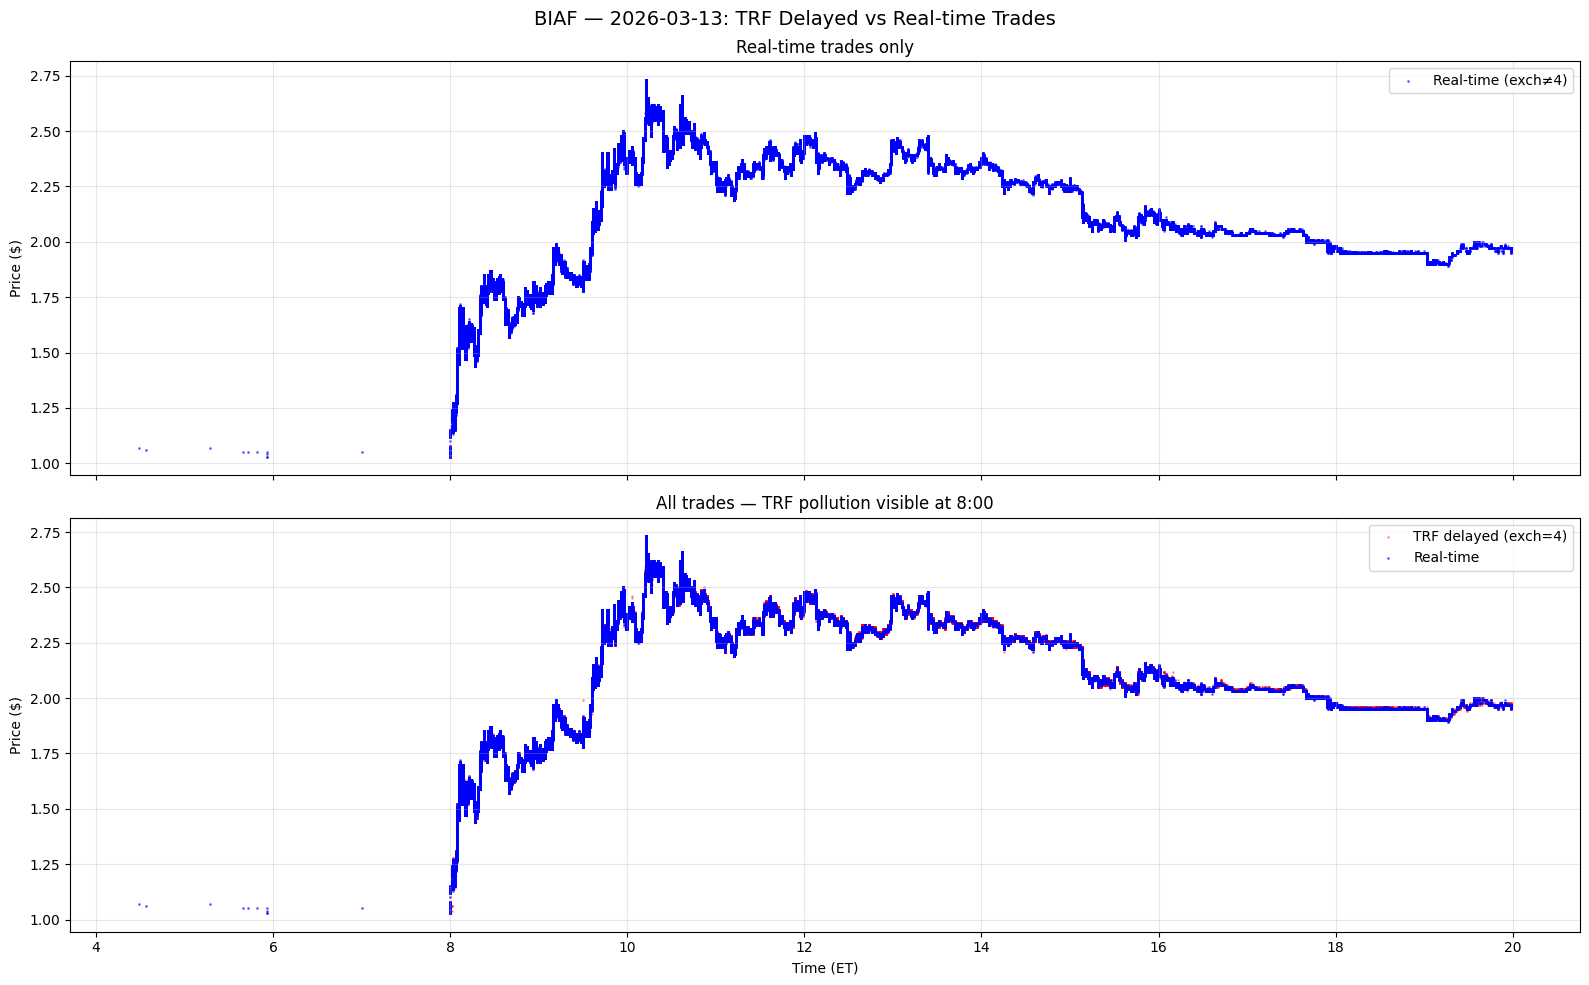

In [11]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(16, 10), sharex=True)
fig.suptitle(f"{TICKER} — {DATE}: TRF Delayed vs Real-time Trades", fontsize=14)

# Plot real-time trades
ax1.scatter(sip_et_hours[is_real], prices[is_real], s=1, alpha=0.5, c='blue', label='Real-time (exch≠4)')
ax1.set_ylabel("Price ($)")
ax1.set_title("Real-time trades only")
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot all trades (TRF + real)
ax2.scatter(sip_et_hours[is_trf], prices[is_trf], s=1, alpha=0.3, c='red', label='TRF delayed (exch=4)')
ax2.scatter(sip_et_hours[is_real], prices[is_real], s=1, alpha=0.5, c='blue', label='Real-time')
ax2.set_ylabel("Price ($)")
ax2.set_xlabel("Time (ET)")
ax2.set_title("All trades — TRF pollution visible at 8:00")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Zoom into 8:00 ET burst

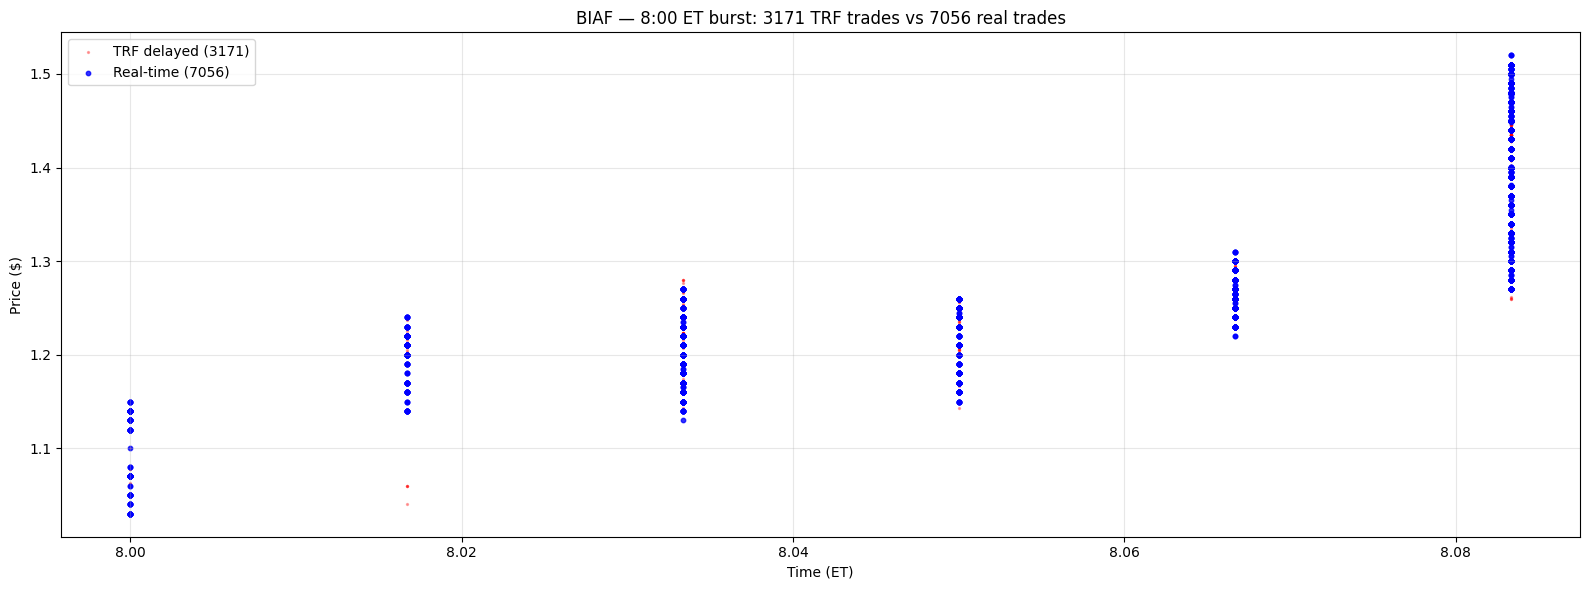

In [12]:
# Zoom: 7:55 - 8:05 ET
mask_zoom = (sip_et_hours >= 7.9) & (sip_et_hours < 8.1)

fig, ax = plt.subplots(figsize=(16, 6))
ax.scatter(sip_et_hours[mask_zoom & is_trf], prices[mask_zoom & is_trf], 
           s=2, alpha=0.3, c='red', label=f'TRF delayed ({(mask_zoom & is_trf).sum()})')
ax.scatter(sip_et_hours[mask_zoom & is_real], prices[mask_zoom & is_real], 
           s=10, alpha=0.8, c='blue', label=f'Real-time ({(mask_zoom & is_real).sum()})')
ax.set_xlabel("Time (ET)")
ax.set_ylabel("Price ($)")
ax.set_title(f"{TICKER} — 8:00 ET burst: {(mask_zoom & is_trf).sum()} TRF trades vs {(mask_zoom & is_real).sum()} real trades")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 4. Delta distribution (sip - participant)

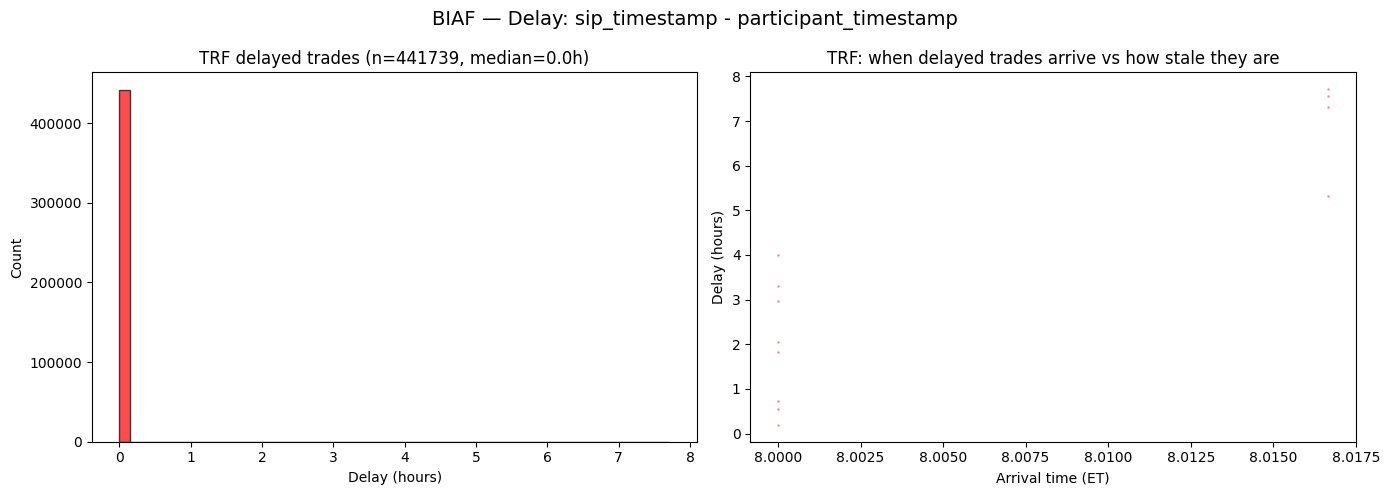

In [13]:
delta_hours = delta_s / 3600

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f"{TICKER} — Delay: sip_timestamp - participant_timestamp", fontsize=14)

# Histogram of delta for TRF trades
trf_delta = delta_hours[is_trf]
trf_delta_valid = trf_delta[trf_delta > 0]
if len(trf_delta_valid) > 0:
    ax1.hist(trf_delta_valid, bins=50, edgecolor='black', alpha=0.7, color='red')
    ax1.set_xlabel("Delay (hours)")
    ax1.set_ylabel("Count")
    ax1.set_title(f"TRF delayed trades (n={len(trf_delta_valid)}, median={np.median(trf_delta_valid):.1f}h)")

# Delta vs arrival time for TRF
trf_mask = is_trf & (delta_hours > 0.01)
ax2.scatter(sip_et_hours[trf_mask], delta_hours[trf_mask], s=1, alpha=0.3, c='red')
ax2.set_xlabel("Arrival time (ET)")
ax2.set_ylabel("Delay (hours)")
ax2.set_title("TRF: when delayed trades arrive vs how stale they are")

plt.tight_layout()
plt.show()

## 5. Price distortion: what BarBuilder / DataLoader sees vs reality

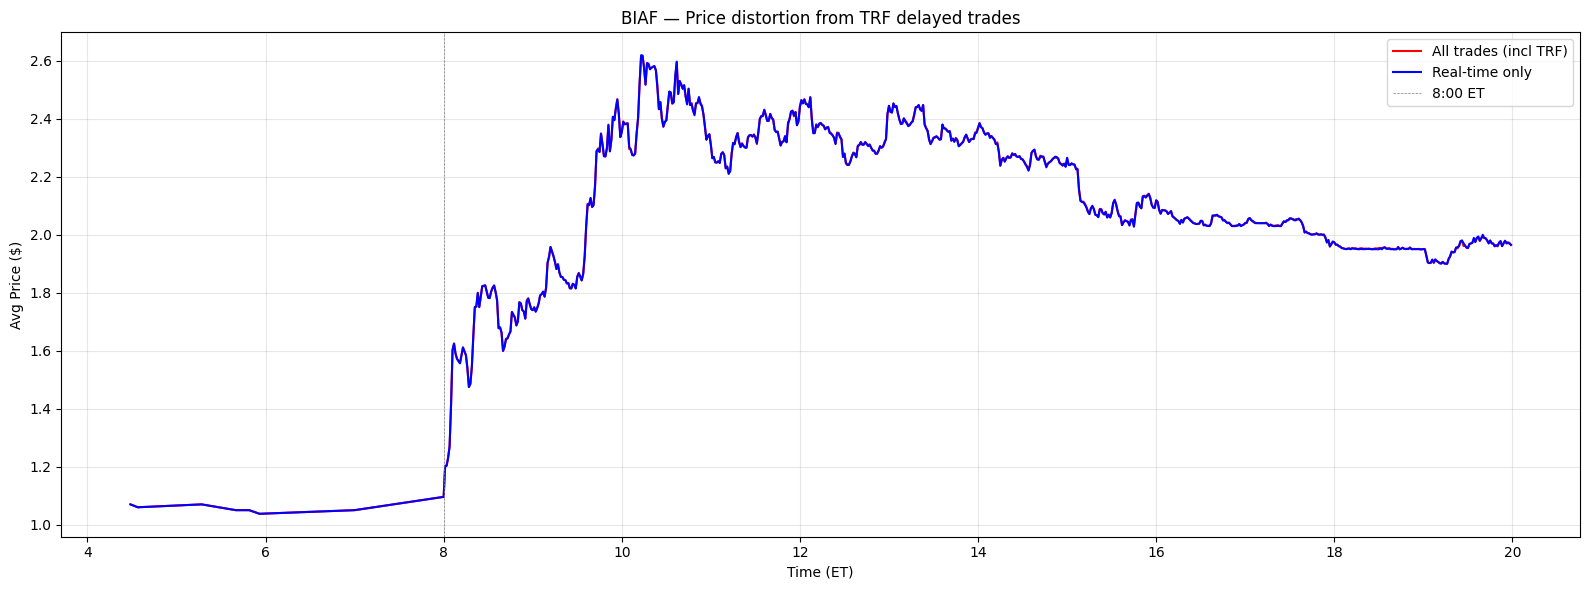

Max price distortion: +0.4% at 10h24m ET


In [14]:
# Compute 1-minute average price: all trades vs real-time only
from collections import defaultdict

def minute_avg(et_hours, prices, mask):
    """Compute per-minute average price."""
    mins = defaultdict(list)
    for h, p in zip(et_hours[mask], prices[mask]):
        key = int(h * 60)  # minute of day
        mins[key].append(p)
    sorted_mins = sorted(mins.keys())
    return np.array([m / 60 for m in sorted_mins]), np.array([np.mean(mins[m]) for m in sorted_mins])

time_all, price_all = minute_avg(sip_et_hours, prices, np.ones(len(prices), dtype=bool))
time_real, price_real = minute_avg(sip_et_hours, prices, is_real)

fig, ax = plt.subplots(figsize=(16, 6))
ax.plot(time_all, price_all, label='All trades (incl TRF)', color='red', linewidth=1.5)
ax.plot(time_real, price_real, label='Real-time only', color='blue', linewidth=1.5)
ax.axvline(x=8.0, color='gray', linestyle='--', linewidth=0.5, label='8:00 ET')
ax.set_xlabel("Time (ET)")
ax.set_ylabel("Avg Price ($)")
ax.set_title(f"{TICKER} — Price distortion from TRF delayed trades")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Show max distortion
if len(time_all) > 0 and len(time_real) > 0:
    # Find overlapping range
    from bisect import bisect_left
    distortions = []
    for i, t in enumerate(time_real):
        idx = bisect_left(time_all, t)
        if idx < len(time_all) and abs(time_all[idx] - t) < 0.02:
            diff_pct = (price_all[idx] - price_real[i]) / price_real[i] * 100
            distortions.append((t, diff_pct))
    if distortions:
        max_dist = max(distortions, key=lambda x: abs(x[1]))
        print(f"Max price distortion: {max_dist[1]:+.1f}% at {int(max_dist[0])}h{int((max_dist[0]%1)*60):02d}m ET")

## 6. Impact on other high-volume tickers

In [15]:
# Check TRF delay impact across top tickers
tickers = ['BIAF', 'ISPC', 'AIFF', 'EONR', 'MEHA', 'ELPW', 'CXAI', 'PAYP', 'KIDZ', 'DEVS']

print(f"{'Ticker':>8} {'Total':>8} {'TRF':>8} {'TRF%':>6} {'TRF@8:00':>9} {'Real@8:00':>10}")
print(f"{'─'*55}")

for ticker in tickers:
    q = f'''
    SELECT 
        count(*) as total,
        countIf(exchange = 4) as trf,
        countIf(exchange = 4 AND sip_timestamp >= 1773403200000000000 AND sip_timestamp < 1773403260000000000) as trf_8am,
        countIf(exchange != 4 AND sip_timestamp >= 1773403200000000000 AND sip_timestamp < 1773403260000000000) as real_8am
    FROM trades FINAL
    WHERE date = '{DATE}' AND ticker = '{ticker}'
    '''
    r = ch.query(q)
    row = r.result_rows[0]
    trf_pct = row[1] / row[0] * 100 if row[0] > 0 else 0
    print(f'{ticker:>8} {row[0]:>8} {row[1]:>8} {trf_pct:>5.1f}% {row[2]:>9} {row[3]:>10}')

  Ticker    Total      TRF   TRF%  TRF@8:00  Real@8:00
───────────────────────────────────────────────────────
    BIAF   862725   441739  51.2%        29        109
    ISPC   383311   134289  35.0%     30228       1311
    AIFF   282846   153837  54.4%      1559        759
    EONR   274561   152483  55.5%     35481        105
    MEHA   188561    90799  48.2%        18          3
    ELPW   182883    61636  33.7%     15538        158
    CXAI   163663    64612  39.5%     16373         50
    PAYP   161646    68739  42.5%     12429         31
    KIDZ   157789    43211  27.4%     20274        526
    DEVS   120263    50639  42.1%        31          0
